# 04 · 감성 분석

KNU 한국어 감성사전으로 기사별 감성 점수를 매기고, 분포·월별 추이·대표 기사를 본다.

- 감성어는 명사만으로는 잡히지 않으므로 `Okt.pos(stem=True)`로 형용사·동사 어간까지 복원해 매칭한다.
- 무거운 로직은 `src/sentiment.py`에 있고, 여기서는 import해서 분석/시각화만 한다.

In [1]:
# 셋업
import sys; sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

import config
from src import preprocess as pp
from src import sentiment as st

config.set_korean_font()

'Malgun Gothic'

## 1. 감성 점수 (캐시 로드)

전수 점수화는 약 1~2분 걸리므로 `data/processed/news_sentiment.pkl`에 캐시한다.
점수 = 매칭된 감성어 극성(-2~+2)의 합, 부호로 긍정/부정/중립을 분류한다.

In [2]:
CACHE = "news_sentiment"
try:
    df = pp.load_processed(CACHE)
    print("캐시 로드:", df.shape)
except FileNotFoundError:
    print("캐시 없음 → 감성 점수화 (약 1~2분)...")
    base = pp.load_processed("news_tokenized")
    df = st.score_dataframe(base, text_col="본문")
    pp.save_processed(df, CACHE)
    print("저장 완료:", df.shape)

df[["제목", "senti_score", "senti_pos", "senti_neg", "senti_label"]].head()

캐시 로드: (20079, 26)


,제목,senti_score,senti_pos,senti_neg,senti_label
0,"서산시 인지면 새마을남녀지도자협의회, '사랑의 김장 나눔'으로 사랑 전달",5,3,1,positive
1,"""나 혼자 살다 죽다""...고독사 늘고 고립은 심화",-1,0,1,negative
2,'나혼자 산다' 36%...국민 5명 중 1명 노인,-1,0,1,negative
3,"서산시, 2025년 찾아가는 보건복지 서비스 우수사례 시상식 개최",1,3,2,positive
4,증평지역 기관 단체의 그침 없는 이웃 사랑 귀감,3,2,1,positive


## 2. 감성 분포

senti_label
positive    12281
neutral      3120
negative     4678

평균 점수: 1.473


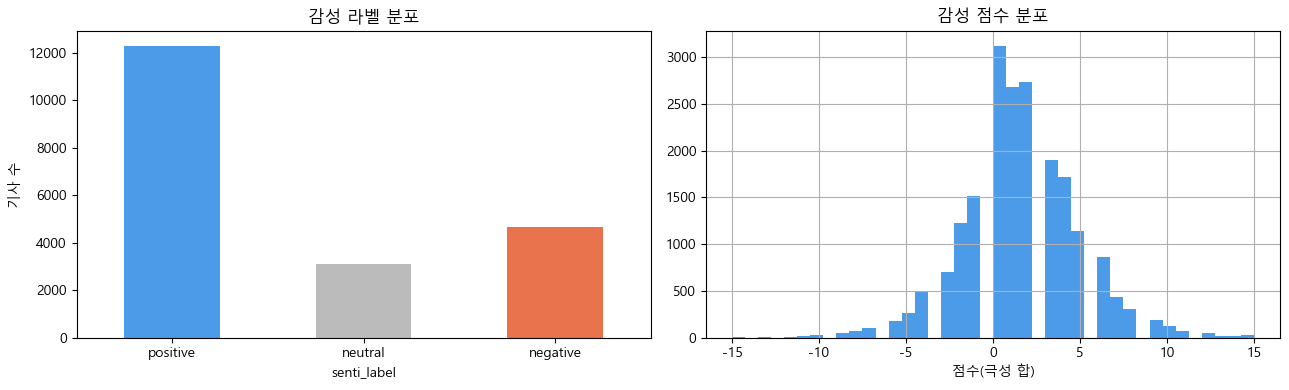

In [3]:
dist = df["senti_label"].value_counts().reindex(["positive", "neutral", "negative"])
print(dist.to_string())
print("\n평균 점수:", round(df["senti_score"].mean(), 3))

colors = {"positive": "#4C9BE8", "neutral": "#BBBBBB", "negative": "#E8734C"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dist.plot.bar(ax=axes[0], color=[colors[k] for k in dist.index])
axes[0].set_title("감성 라벨 분포")
axes[0].set_ylabel("기사 수")
axes[0].tick_params(axis="x", rotation=0)

df["senti_score"].clip(-15, 15).hist(bins=40, ax=axes[1], color="#4C9BE8")
axes[1].set_title("감성 점수 분포")
axes[1].set_xlabel("점수(극성 합)")
fig.tight_layout()
fig.savefig(config.FIG_DIR / "04_sentiment_dist.png", dpi=150)
plt.show()

## 3. 월별 감성 추이

월별 평균 감성 점수와 긍/부정 기사 비중 변화.

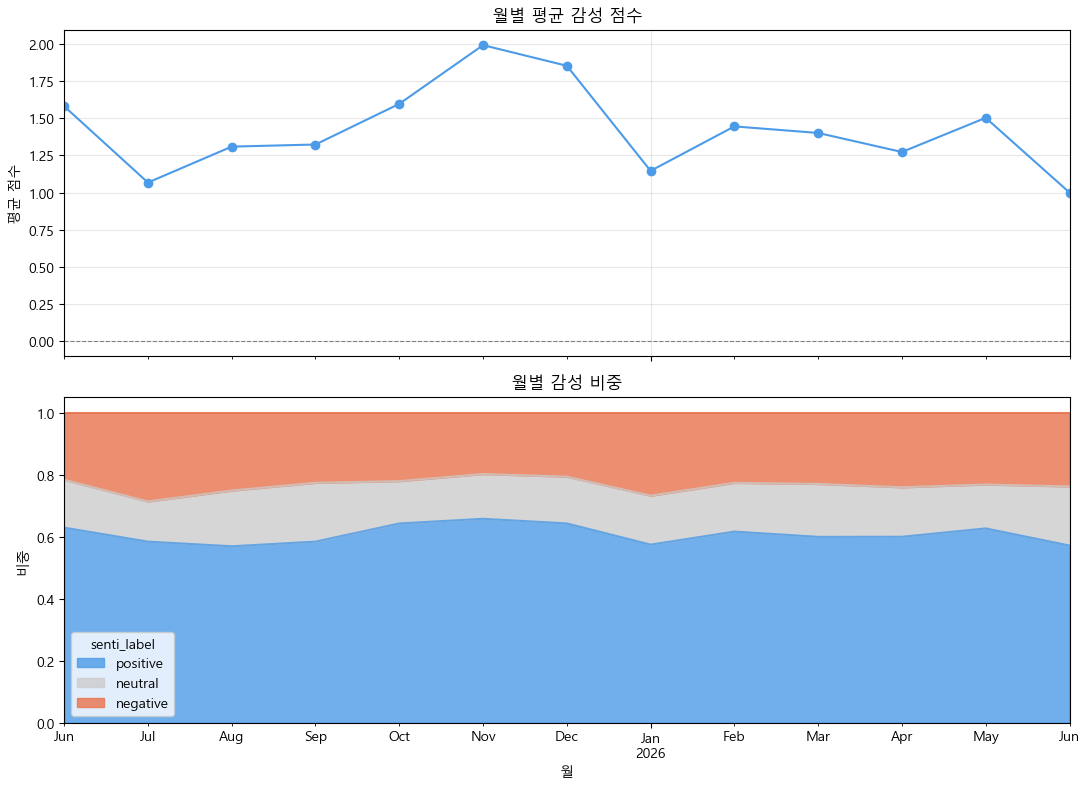

In [4]:
g = df.set_index("날짜").resample("ME")
monthly_score = g["senti_score"].mean()
monthly_label = df.set_index("날짜").groupby([pd.Grouper(freq="ME"), "senti_label"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
monthly_score.plot(marker="o", ax=axes[0], color="#4C9BE8")
axes[0].axhline(0, color="gray", lw=0.8, ls="--")
axes[0].set_title("월별 평균 감성 점수")
axes[0].set_ylabel("평균 점수")
axes[0].grid(alpha=0.3)

monthly_ratio = monthly_label.div(monthly_label.sum(axis=1), axis=0)
monthly_ratio[["positive", "neutral", "negative"]].plot.area(
    ax=axes[1], color=["#4C9BE8", "#CCCCCC", "#E8734C"], alpha=0.8)
axes[1].set_title("월별 감성 비중")
axes[1].set_ylabel("비중")
axes[1].set_xlabel("월")
fig.tight_layout()
fig.savefig(config.FIG_DIR / "04_sentiment_monthly.png", dpi=150)
plt.show()

## 4. 대표 기사 (긍정/부정 상위)

In [5]:
cols = ["일자", "언론사", "제목", "senti_score"]
print("=== 긍정 점수 상위 5 ===")
for _, r in df.nlargest(5, "senti_score")[cols].iterrows():
    print(f"[{r['senti_score']:+d}] {r['제목']}  ({r['언론사']})")
print("\n=== 부정 점수 상위 5 ===")
for _, r in df.nsmallest(5, "senti_score")[cols].iterrows():
    print(f"[{r['senti_score']:+d}] {r['제목']}  ({r['언론사']})")

# 표 저장
df[["일자", "언론사", "제목", "senti_score", "senti_label"]].to_csv(
    config.TABLE_DIR / "04_sentiment.csv", index=False, encoding="utf-8-sig")

=== 긍정 점수 상위 5 ===
[+22] 공주시 옥룡동 복지봉사단, 주거환경 개선 봉사활동 '이웃 사랑을 실천과 삶의 질 향상에 힘을 보태'  (대전일보)
[+20] 익산시, 복지 안전 서비스 개선 ‘행정안전부 장관상’ 수상  (전북도민일보)
[+18] 부산시, 행안부 주관 '1분기 적극행정을 통한 규제개선' 우수사례 최종 선정  (부산일보)
[+18] 남구, 읍면동 복지 안전서비스 경진대회 장관상  (경상일보)
[+17] 광진구, 2025년 지방자치단체 혁신평가 ‘종합 우수’ 등급  (문화일보)

=== 부정 점수 상위 5 ===
[-19] 고령층 우울증 부르는 관절염, 조기 진단 관리 중요  (국민일보)
[-19] [온누리] 애정망상증  (새전북신문)
[-17] [자치칼럼]강원형 재난정책,  이제는‘돌봄의 관점’이 필요하다  (강원일보)
[-15] 홈앤쇼핑, 장애인 표준사업장 지분 투자 “장애인 일자리 확대”  (서울경제)
[-14] [기고]주택용 소방시설과 함께 안전한 명절 보내세요  (경상일보)


## 메모

- 이 코퍼스는 복지·나눔·지원 기사가 많아 **긍정 편향**이 자연스럽다.
- KNU 사전은 단어형(공백 없는) 한글 엔트리만 사용했다. 여러 어절 표현·문맥 부정(예: "외롭지 않다")은
  반영되지 않으므로, 점수는 절대값보다 **상대 비교(월별·토픽별)** 로 해석하는 것이 안전하다.
- 정교화하려면 부정어 처리, 도메인 감성어 가중, 또는 사전학습 감성 분류 모델로 교체할 수 있다.